In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns       
import numpy as np

In [3]:
df=pd.read_csv('ai_job_dataset.csv')

In [7]:
df.columns

Index(['job_id', 'job_title', 'salary_usd', 'salary_currency',
       'experience_level', 'employment_type', 'company_location',
       'company_size', 'employee_residence', 'remote_ratio', 'required_skills',
       'education_required', 'years_experience', 'industry', 'posting_date',
       'application_deadline', 'job_description_length', 'benefits_score',
       'company_name'],
      dtype='object')

# 数据处理

In [4]:
#required_skills 列是逗号分隔的字符串，拆分成多列的 0/1 变量
# 1. 先拆分成多行
df_long = df.assign(skill=df['required_skills'].str.split(',')).explode('skill')

# 2. 去掉前后空格
df_long['skill'] = df_long['skill'].str.strip()

# 3. 用 pd.get_dummies 转成 0/1 变量
df_dummies = pd.get_dummies(df_long['skill'], prefix='skill')

# 4. 合并回原表（注意用 groupby 聚合保证同一岗位多个技能合并成一行）
df_skills = pd.concat([df_long.drop(columns=['skill']), df_dummies], axis=1)
df_skills = df_skills.groupby(df_skills.index).max()  # 每行取最大值，确保多技能合并

# EDA

In [34]:
df['job_title'].value_counts()

job_title
Machine Learning Researcher    808
AI Software Engineer           784
Autonomous Systems Engineer    777
Machine Learning Engineer      772
AI Architect                   771
Head of AI                     765
NLP Engineer                   762
Robotics Engineer              759
Data Analyst                   759
AI Research Scientist          756
Data Engineer                  749
AI Product Manager             743
Research Scientist             742
Principal Data Scientist       734
AI Specialist                  728
ML Ops Engineer                725
Computer Vision Engineer       724
Data Scientist                 720
Deep Learning Engineer         718
AI Consultant                  704
Name: count, dtype: int64

In [15]:
df.describe()

,salary_usd,remote_ratio,years_experience,job_description_length,benefits_score
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,115348.965133,49.483333,6.253200,1503.314733,7.504273
std,60260.940438,40.812712,5.545768,576.127083,1.450870
min,32519.000000,0.000000,0.000000,500.000000,5.000000
25%,70179.750000,0.000000,2.000000,1003.750000,6.200000
50%,99705.000000,50.000000,5.000000,1512.000000,7.500000
75%,146408.500000,100.000000,10.000000,2000.000000,8.800000
max,399095.000000,100.000000,19.000000,2499.000000,10.000000


In [35]:
df

,job_id,job_title,salary_usd,salary_currency,experience_level,employment_type,company_location,company_size,employee_residence,remote_ratio,required_skills,education_required,years_experience,industry,posting_date,application_deadline,job_description_length,benefits_score,company_name
0,AI00001,AI Research Scientist,90376,USD,SE,CT,China,M,China,50,"Tableau, PyTorch, Kubernetes, Linux, NLP",Bachelor,9,Automotive,2024-10-18,2024-11-07,1076,5.9,Smart Analytics
1,AI00002,AI Software Engineer,61895,USD,EN,CT,Canada,M,Ireland,100,"Deep Learning, AWS, Mathematics, Python, Docker",Master,1,Media,2024-11-20,2025-01-11,1268,5.2,TechCorp Inc
2,AI00003,AI Specialist,152626,USD,MI,FL,Switzerland,L,South Korea,0,"Kubernetes, Deep Learning, Java, Hadoop, NLP",Associate,2,Education,2025-03-18,2025-04-07,1974,9.4,Autonomous Tech
3,AI00004,NLP Engineer,80215,USD,SE,FL,India,M,India,50,"Scala, SQL, Linux, Python",PhD,7,Consulting,2024-12-23,2025-02-24,1345,8.6,Future Systems
4,AI00005,AI Consultant,54624,EUR,EN,PT,France,S,Singapore,100,"MLOps, Java, Tableau, Python",Master,0,Media,2025-04-15,2025-06-23,1989,6.6,Advanced Robotics
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14995,AI14996,Robotics Engineer,38604,USD,EN,FL,Finland,S,Finland,50,"Java, Kubernetes, Azure",Bachelor,1,Energy,2025-02-06,2025-03-25,1635,7.9,Advanced Robotics
14996,AI14997,Machine Learning Researcher,57811,GBP,EN,CT,United Kingdom,M,United Kingdom,0,"Mathematics, Docker, SQL, Deep Learning",Master,0,Government,2024-10-16,2024-10-30,1624,8.2,Smart Analytics
14997,AI14998,NLP Engineer,189490,USD,EX,CT,South Korea,L,South Korea,50,"Scala, Spark, NLP",Associate,17,Manufacturing,2024-03-19,2024-05-02,1336,7.4,AI Innovations
14998,AI14999,Head of AI,79461,EUR,EN,FT,Netherlands,M,Netherlands,0,"Java, Computer Vision, Python, TensorFlow",PhD,1,Real Estate,2024-03-22,2024-04-23,1935,5.6,Smart Analytics


count     15000.000000
mean     115348.965133
std       60260.940438
min       32519.000000
25%       70179.750000
50%       99705.000000
75%      146408.500000
max      399095.000000
Name: salary_usd, dtype: float64


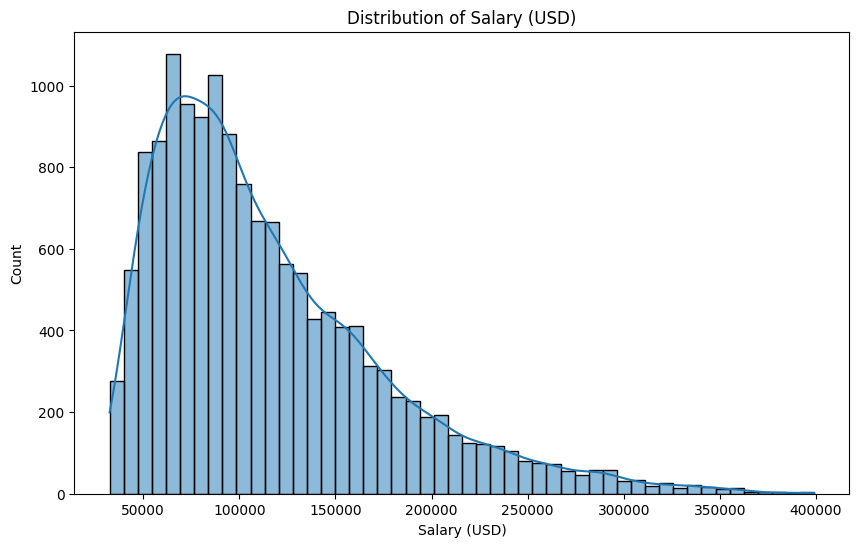

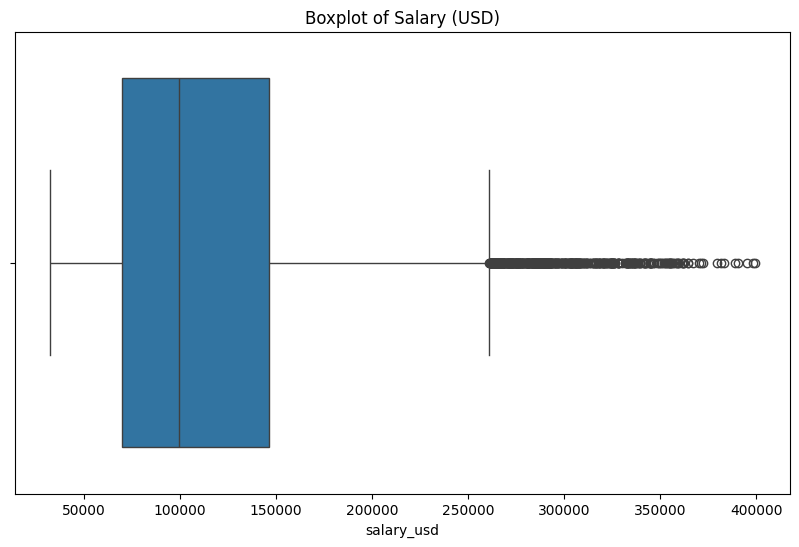

In [5]:
# salary_usd 工资本身分布
print(df['salary_usd'].describe())
# 直方图 + KDE
plt.figure(figsize=(10,6))
sns.histplot(df['salary_usd'], bins=50, kde=True)
plt.title("Distribution of Salary (USD)")
plt.xlabel("Salary (USD)")
plt.ylabel("Count")
plt.show()

# 箱线图（看异常值）
plt.figure(figsize=(10,6))
sns.boxplot(x=df['salary_usd'])
plt.title("Boxplot of Salary (USD)")
plt.show()


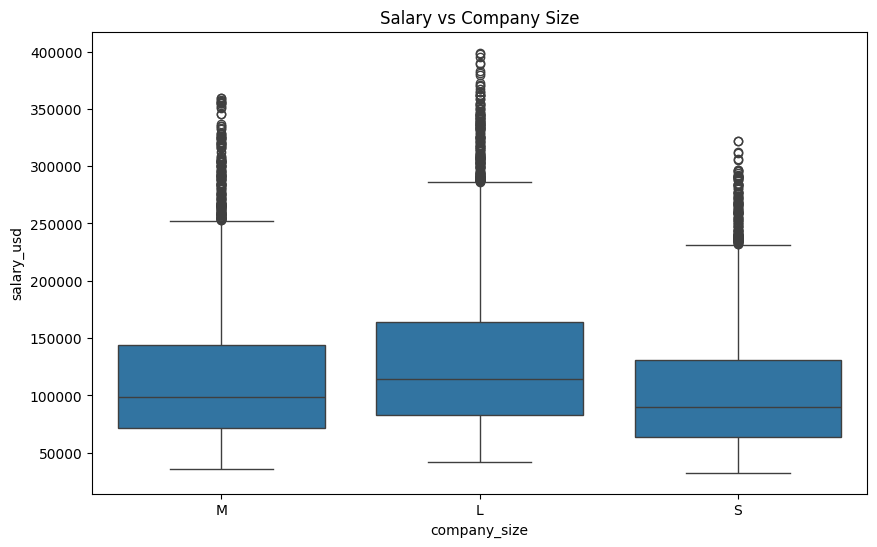

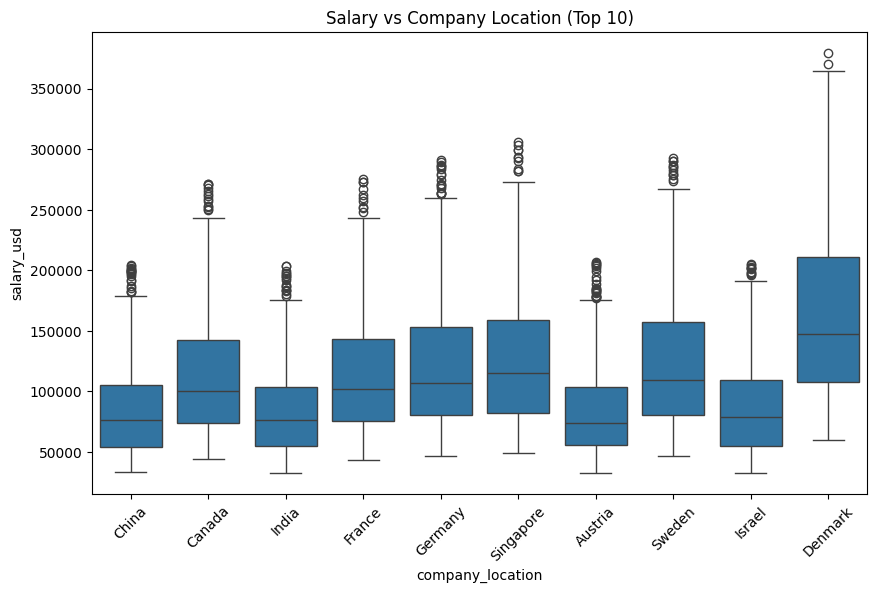

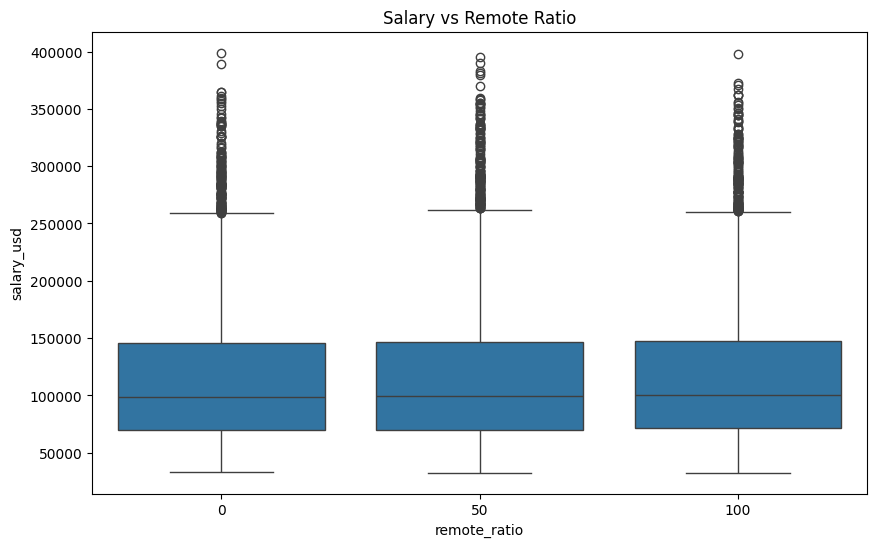

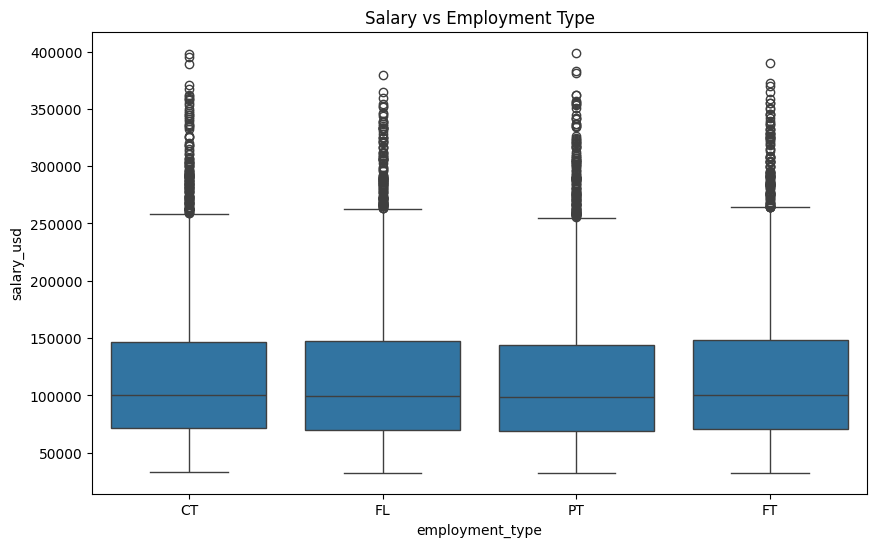

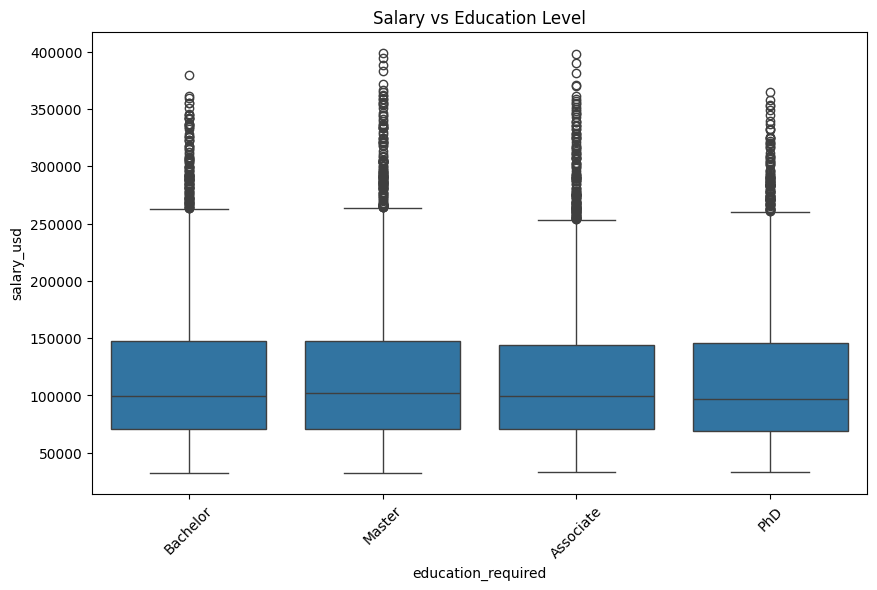

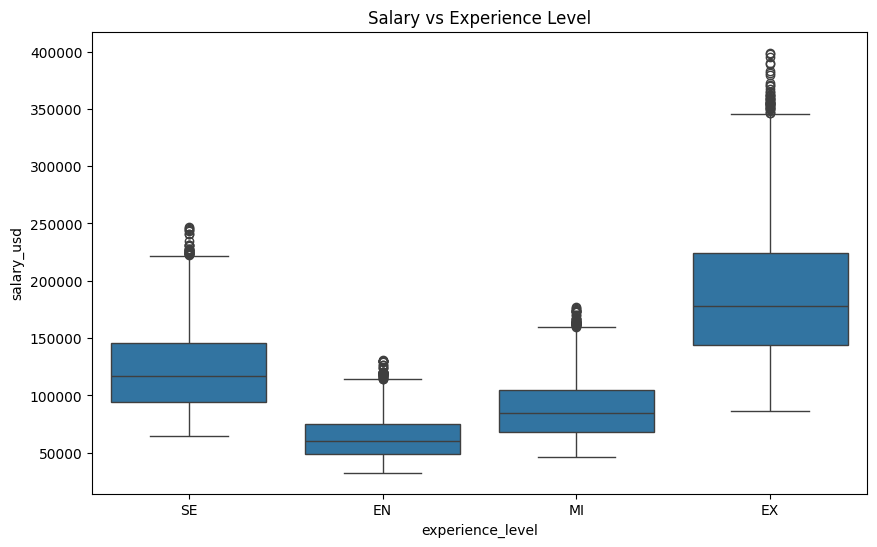

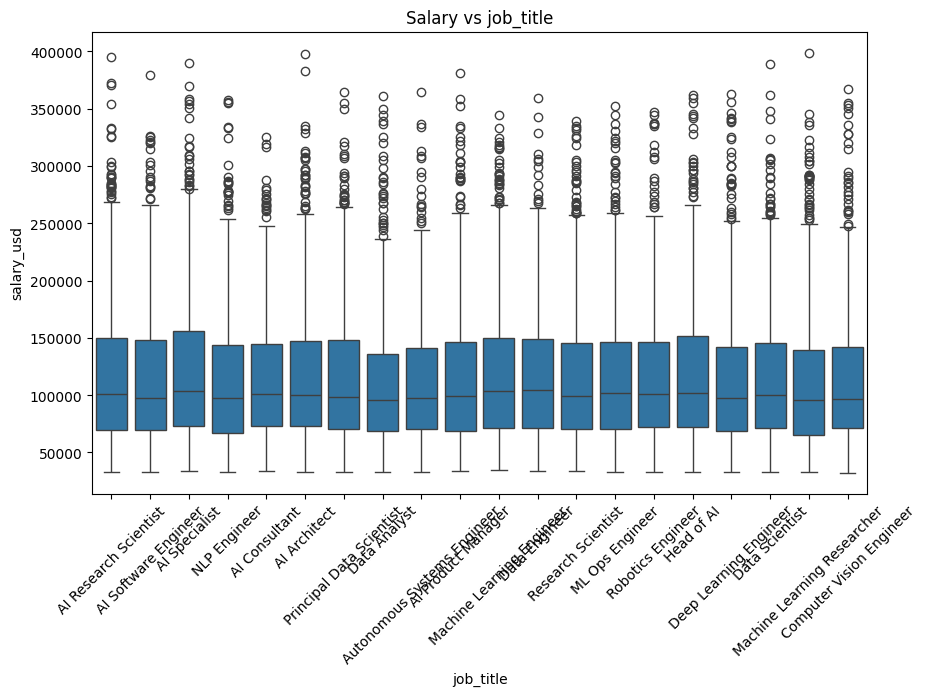

In [8]:
##与公司规模 (company_size) 的关系
plt.figure(figsize=(10,6))
sns.boxplot(x='company_size', y='salary_usd', data=df)
plt.title("Salary vs Company Size")
plt.show()

##与公司位置 (company_location) 的关系
top_countries = df['company_location'].value_counts().nlargest(10).index
plt.figure(figsize=(10,6))
sns.boxplot(x='company_location', y='salary_usd',
            data=df[df['company_location'].isin(top_countries)])
plt.xticks(rotation=45)
plt.title("Salary vs Company Location (Top 10)")
plt.show()


##与远程比例 (remote_ratio) 的关系
plt.figure(figsize=(10,6))
sns.boxplot(x='remote_ratio', y='salary_usd', data=df)
plt.title("Salary vs Remote Ratio")
plt.show()

##与工作类型（employment_type） 的关系
plt.figure(figsize=(10,6))
sns.boxplot(x='employment_type', y='salary_usd', data=df)
plt.title("Salary vs Employment Type")
plt.show()


###与教育水平（education_required） 的关系
plt.figure(figsize=(10,6))
sns.boxplot(x='education_required', y='salary_usd', data=df)
plt.xticks(rotation=45)
plt.title("Salary vs Education Level")
plt.show()

##与经验水平（experience_level） 的关系
plt.figure(figsize=(10,6))
sns.boxplot(x='experience_level', y='salary_usd', data=df)
plt.title("Salary vs Experience Level")
plt.show()


##与job_title 的关系
plt.figure(figsize=(10,6))
sns.boxplot(x='job_title', y='salary_usd', data=df)
plt.title("Salary vs job_title")
plt.xticks(rotation=45)
plt.show()

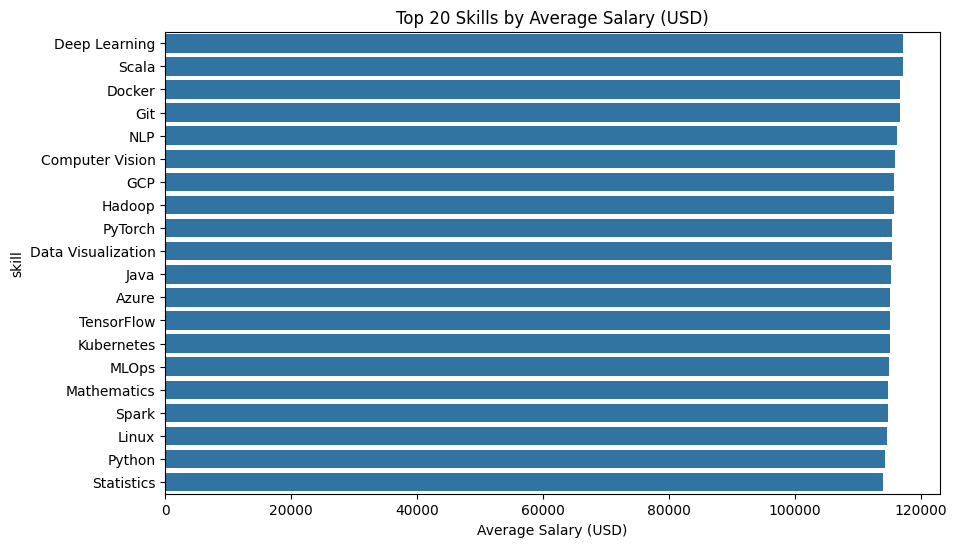

In [ ]:
#工资与技能（required_skill）的关系
# 先把技能展开成多行
df_long = df.assign(skill=df['required_skills'].str.split(',')).explode('skill')
df_long['skill'] = df_long['skill'].str.strip()

# 按技能计算平均工资
skill_salary = df_long.groupby('skill')['salary_usd'].mean().sort_values(ascending=False).head(20)

plt.figure(figsize=(10,6))
sns.barplot(x=skill_salary.values, y=skill_salary.index)
plt.title("Top 20 Skills by Average Salary (USD)")
plt.xlabel("Average Salary (USD)")
plt.show()

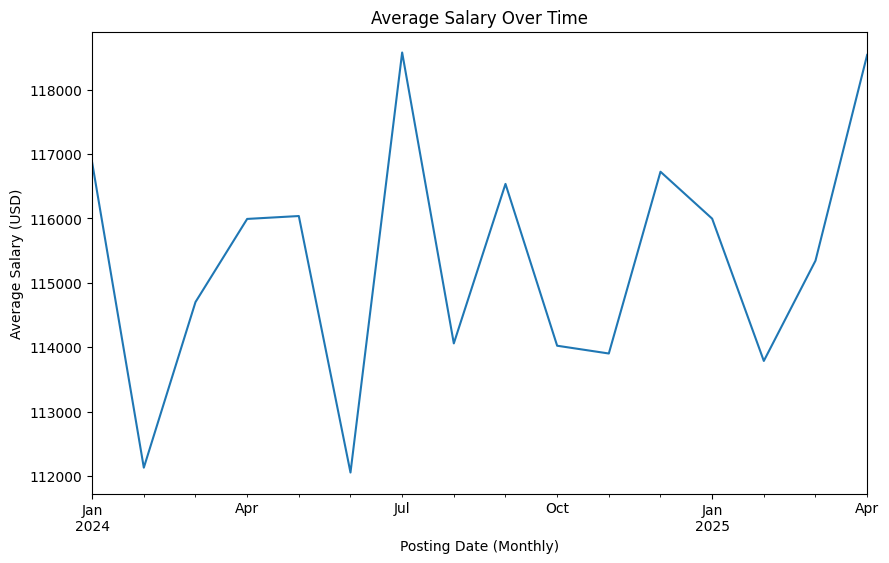

In [31]:
##时间趋势：工资随时间变化
df['posting_date'] = pd.to_datetime(df['posting_date'])
df_time = df.groupby(df['posting_date'].dt.to_period("M"))['salary_usd'].mean()

df_time.plot(figsize=(10,6))
plt.title("Average Salary Over Time")
plt.ylabel("Average Salary (USD)")
plt.xlabel("Posting Date (Monthly)")
plt.show()

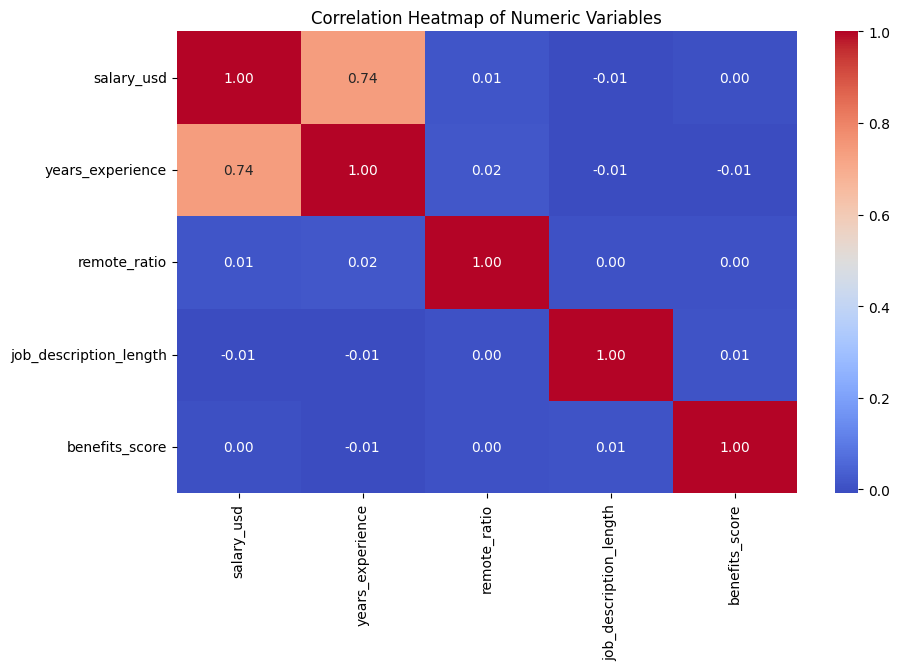

In [32]:
# 选择数值型变量
num_cols = ['salary_usd', 'years_experience', 'remote_ratio','job_description_length', 'benefits_score']

corr = df[num_cols].corr()

plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap of Numeric Variables")
plt.show()

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_top_skills_all_jobs(df_skills, n=5):
    # 1. 找出技能列
    skill_cols = [col for col in df_skills.columns if col.startswith("skill_")]

    # 2. 按 job_title 分组，统计每个技能出现次数
    job_skill_counts = df_skills.groupby("industry")[skill_cols].sum()

    # 3. 为每个 job_title 画图
    for job, row in job_skill_counts.iterrows():
        topn = row.sort_values(ascending=False).head(n)

        plt.figure(figsize=(8, 4))
        sns.barplot(x=topn.values, y=topn.index, palette="Blues_r")
        plt.title(f"{job} 岗位最常需要的技能 Top{n}")
        plt.xlabel("count")
        plt.ylabel("skills")
        plt.tight_layout()
        plt.show()


In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_top_skills_global(df_skills, n=10):
    # 1. 找出技能列
    skill_cols = [col for col in df_skills.columns if col.startswith("skill_")]

    # 2. 统计所有岗位的技能总次数
    skill_counts = df_skills[skill_cols].sum().sort_values(ascending=False).head(n)

    # 3. 画图
    plt.figure(figsize=(8, 5))
    sns.barplot(x=skill_counts.values, y=skill_counts.index, palette="Blues_r")
    plt.title(f"AI 岗位需求最多的技能 Top{n} (全局)")
    plt.xlabel("出现次数")
    plt.ylabel("技能")
    plt.tight_layout()
    plt.show()


/var/folders/k7/3d7f1jzs6t18v3frf9bl8ysr0000gn/T/ipykernel_31059/1134402008.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=skill_counts.values, y=skill_counts.index, palette="Blues_r")
/var/folders/k7/3d7f1jzs6t18v3frf9bl8ysr0000gn/T/ipykernel_31059/1134402008.py:17: UserWarning: Glyph 20986 (\N{CJK UNIFIED IDEOGRAPH-51FA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/k7/3d7f1jzs6t18v3frf9bl8ysr0000gn/T/ipykernel_31059/1134402008.py:17: UserWarning: Glyph 29616 (\N{CJK UNIFIED IDEOGRAPH-73B0}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/k7/3d7f1jzs6t18v3frf9bl8ysr0000gn/T/ipykernel_31059/1134402008.py:17: UserWarning: Glyph 27425 (\N{CJK UNIFIED IDEOGRAPH-6B21}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/k7/3d7f1jzs6t18v3frf9bl8ysr0000gn/T/ipykernel_31059/113

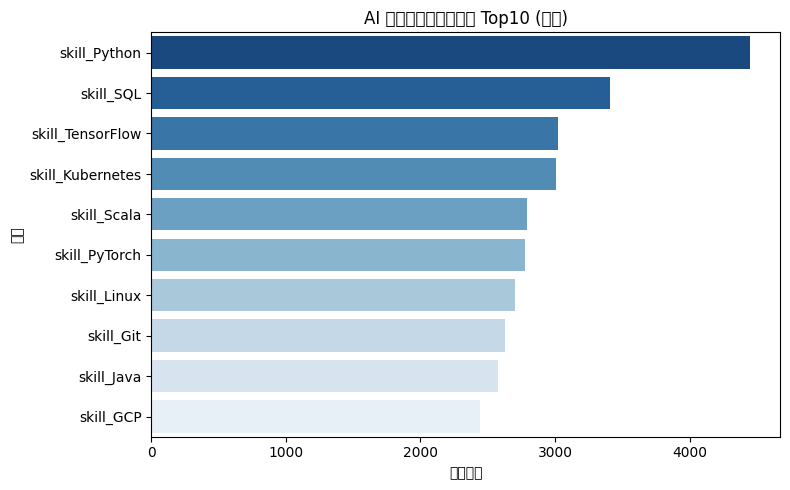

In [15]:
plot_top_skills_global(df_skills, n=10)


/var/folders/k7/3d7f1jzs6t18v3frf9bl8ysr0000gn/T/ipykernel_31059/2879734636.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=topn.values, y=topn.index, palette="Blues_r")
/var/folders/k7/3d7f1jzs6t18v3frf9bl8ysr0000gn/T/ipykernel_31059/2879734636.py:20: UserWarning: Glyph 23703 (\N{CJK UNIFIED IDEOGRAPH-5C97}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/k7/3d7f1jzs6t18v3frf9bl8ysr0000gn/T/ipykernel_31059/2879734636.py:20: UserWarning: Glyph 20301 (\N{CJK UNIFIED IDEOGRAPH-4F4D}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/k7/3d7f1jzs6t18v3frf9bl8ysr0000gn/T/ipykernel_31059/2879734636.py:20: UserWarning: Glyph 26368 (\N{CJK UNIFIED IDEOGRAPH-6700}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/k7/3d7f1jzs6t18v3frf9bl8ysr0000gn/T/ipykernel_31059/2879734636.py:20: U

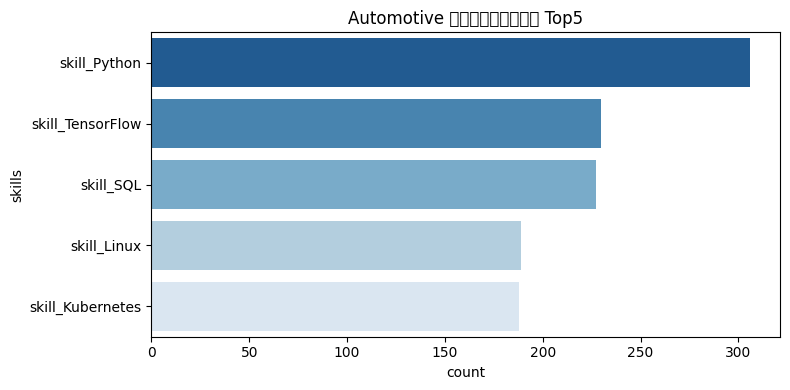

/var/folders/k7/3d7f1jzs6t18v3frf9bl8ysr0000gn/T/ipykernel_31059/2879734636.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=topn.values, y=topn.index, palette="Blues_r")
/var/folders/k7/3d7f1jzs6t18v3frf9bl8ysr0000gn/T/ipykernel_31059/2879734636.py:20: UserWarning: Glyph 23703 (\N{CJK UNIFIED IDEOGRAPH-5C97}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/k7/3d7f1jzs6t18v3frf9bl8ysr0000gn/T/ipykernel_31059/2879734636.py:20: UserWarning: Glyph 20301 (\N{CJK UNIFIED IDEOGRAPH-4F4D}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/k7/3d7f1jzs6t18v3frf9bl8ysr0000gn/T/ipykernel_31059/2879734636.py:20: UserWarning: Glyph 26368 (\N{CJK UNIFIED IDEOGRAPH-6700}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/k7/3d7f1jzs6t18v3frf9bl8ysr0000gn/T/ipykernel_31059/2879734636.py:20: U

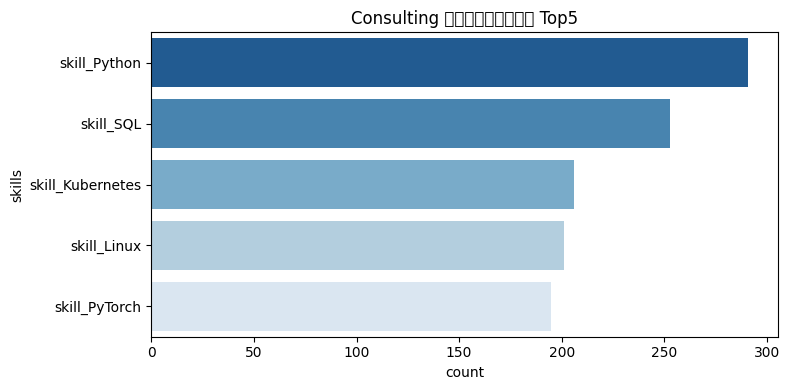

/var/folders/k7/3d7f1jzs6t18v3frf9bl8ysr0000gn/T/ipykernel_31059/2879734636.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=topn.values, y=topn.index, palette="Blues_r")
/var/folders/k7/3d7f1jzs6t18v3frf9bl8ysr0000gn/T/ipykernel_31059/2879734636.py:20: UserWarning: Glyph 23703 (\N{CJK UNIFIED IDEOGRAPH-5C97}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/k7/3d7f1jzs6t18v3frf9bl8ysr0000gn/T/ipykernel_31059/2879734636.py:20: UserWarning: Glyph 20301 (\N{CJK UNIFIED IDEOGRAPH-4F4D}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/k7/3d7f1jzs6t18v3frf9bl8ysr0000gn/T/ipykernel_31059/2879734636.py:20: UserWarning: Glyph 26368 (\N{CJK UNIFIED IDEOGRAPH-6700}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/k7/3d7f1jzs6t18v3frf9bl8ysr0000gn/T/ipykernel_31059/2879734636.py:20: U

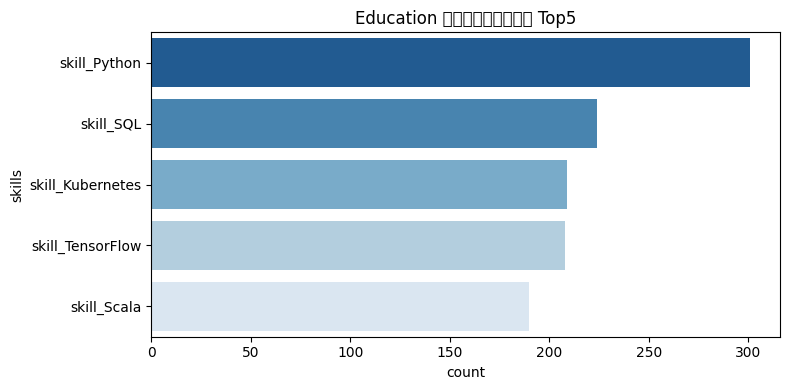

/var/folders/k7/3d7f1jzs6t18v3frf9bl8ysr0000gn/T/ipykernel_31059/2879734636.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=topn.values, y=topn.index, palette="Blues_r")
/var/folders/k7/3d7f1jzs6t18v3frf9bl8ysr0000gn/T/ipykernel_31059/2879734636.py:20: UserWarning: Glyph 23703 (\N{CJK UNIFIED IDEOGRAPH-5C97}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/k7/3d7f1jzs6t18v3frf9bl8ysr0000gn/T/ipykernel_31059/2879734636.py:20: UserWarning: Glyph 20301 (\N{CJK UNIFIED IDEOGRAPH-4F4D}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/k7/3d7f1jzs6t18v3frf9bl8ysr0000gn/T/ipykernel_31059/2879734636.py:20: UserWarning: Glyph 26368 (\N{CJK UNIFIED IDEOGRAPH-6700}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/k7/3d7f1jzs6t18v3frf9bl8ysr0000gn/T/ipykernel_31059/2879734636.py:20: U

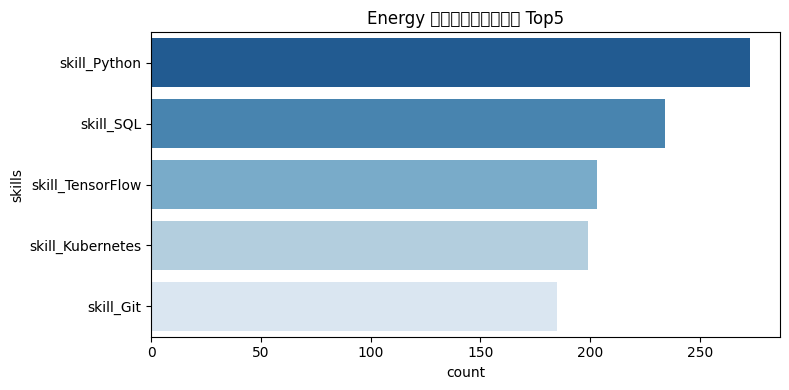

/var/folders/k7/3d7f1jzs6t18v3frf9bl8ysr0000gn/T/ipykernel_31059/2879734636.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=topn.values, y=topn.index, palette="Blues_r")
/var/folders/k7/3d7f1jzs6t18v3frf9bl8ysr0000gn/T/ipykernel_31059/2879734636.py:20: UserWarning: Glyph 23703 (\N{CJK UNIFIED IDEOGRAPH-5C97}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/k7/3d7f1jzs6t18v3frf9bl8ysr0000gn/T/ipykernel_31059/2879734636.py:20: UserWarning: Glyph 20301 (\N{CJK UNIFIED IDEOGRAPH-4F4D}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/k7/3d7f1jzs6t18v3frf9bl8ysr0000gn/T/ipykernel_31059/2879734636.py:20: UserWarning: Glyph 26368 (\N{CJK UNIFIED IDEOGRAPH-6700}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/k7/3d7f1jzs6t18v3frf9bl8ysr0000gn/T/ipykernel_31059/2879734636.py:20: U

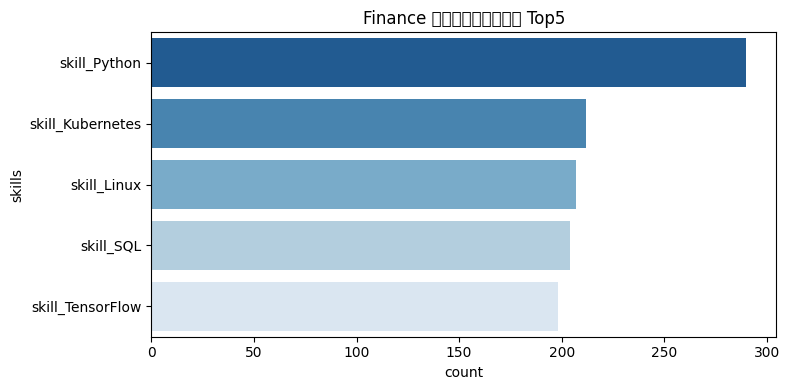

/var/folders/k7/3d7f1jzs6t18v3frf9bl8ysr0000gn/T/ipykernel_31059/2879734636.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=topn.values, y=topn.index, palette="Blues_r")
/var/folders/k7/3d7f1jzs6t18v3frf9bl8ysr0000gn/T/ipykernel_31059/2879734636.py:20: UserWarning: Glyph 23703 (\N{CJK UNIFIED IDEOGRAPH-5C97}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/k7/3d7f1jzs6t18v3frf9bl8ysr0000gn/T/ipykernel_31059/2879734636.py:20: UserWarning: Glyph 20301 (\N{CJK UNIFIED IDEOGRAPH-4F4D}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/k7/3d7f1jzs6t18v3frf9bl8ysr0000gn/T/ipykernel_31059/2879734636.py:20: UserWarning: Glyph 26368 (\N{CJK UNIFIED IDEOGRAPH-6700}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/k7/3d7f1jzs6t18v3frf9bl8ysr0000gn/T/ipykernel_31059/2879734636.py:20: U

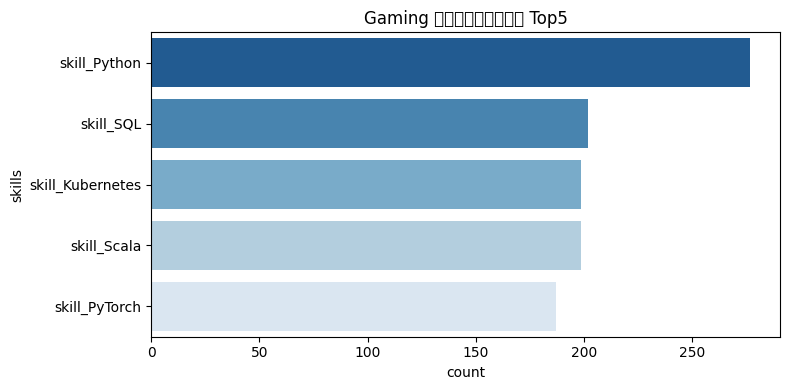

/var/folders/k7/3d7f1jzs6t18v3frf9bl8ysr0000gn/T/ipykernel_31059/2879734636.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=topn.values, y=topn.index, palette="Blues_r")
/var/folders/k7/3d7f1jzs6t18v3frf9bl8ysr0000gn/T/ipykernel_31059/2879734636.py:20: UserWarning: Glyph 23703 (\N{CJK UNIFIED IDEOGRAPH-5C97}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/k7/3d7f1jzs6t18v3frf9bl8ysr0000gn/T/ipykernel_31059/2879734636.py:20: UserWarning: Glyph 20301 (\N{CJK UNIFIED IDEOGRAPH-4F4D}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/k7/3d7f1jzs6t18v3frf9bl8ysr0000gn/T/ipykernel_31059/2879734636.py:20: UserWarning: Glyph 26368 (\N{CJK UNIFIED IDEOGRAPH-6700}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/k7/3d7f1jzs6t18v3frf9bl8ysr0000gn/T/ipykernel_31059/2879734636.py:20: U

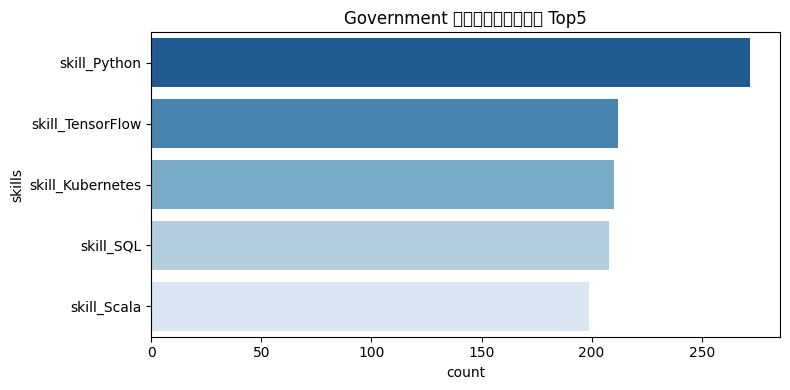

/var/folders/k7/3d7f1jzs6t18v3frf9bl8ysr0000gn/T/ipykernel_31059/2879734636.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=topn.values, y=topn.index, palette="Blues_r")
/var/folders/k7/3d7f1jzs6t18v3frf9bl8ysr0000gn/T/ipykernel_31059/2879734636.py:20: UserWarning: Glyph 23703 (\N{CJK UNIFIED IDEOGRAPH-5C97}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/k7/3d7f1jzs6t18v3frf9bl8ysr0000gn/T/ipykernel_31059/2879734636.py:20: UserWarning: Glyph 20301 (\N{CJK UNIFIED IDEOGRAPH-4F4D}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/k7/3d7f1jzs6t18v3frf9bl8ysr0000gn/T/ipykernel_31059/2879734636.py:20: UserWarning: Glyph 26368 (\N{CJK UNIFIED IDEOGRAPH-6700}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/k7/3d7f1jzs6t18v3frf9bl8ysr0000gn/T/ipykernel_31059/2879734636.py:20: U

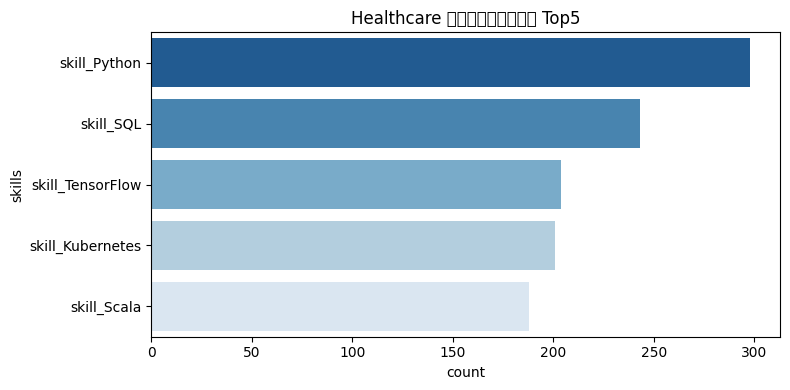

/var/folders/k7/3d7f1jzs6t18v3frf9bl8ysr0000gn/T/ipykernel_31059/2879734636.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=topn.values, y=topn.index, palette="Blues_r")
/var/folders/k7/3d7f1jzs6t18v3frf9bl8ysr0000gn/T/ipykernel_31059/2879734636.py:20: UserWarning: Glyph 23703 (\N{CJK UNIFIED IDEOGRAPH-5C97}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/k7/3d7f1jzs6t18v3frf9bl8ysr0000gn/T/ipykernel_31059/2879734636.py:20: UserWarning: Glyph 20301 (\N{CJK UNIFIED IDEOGRAPH-4F4D}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/k7/3d7f1jzs6t18v3frf9bl8ysr0000gn/T/ipykernel_31059/2879734636.py:20: UserWarning: Glyph 26368 (\N{CJK UNIFIED IDEOGRAPH-6700}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/k7/3d7f1jzs6t18v3frf9bl8ysr0000gn/T/ipykernel_31059/2879734636.py:20: U

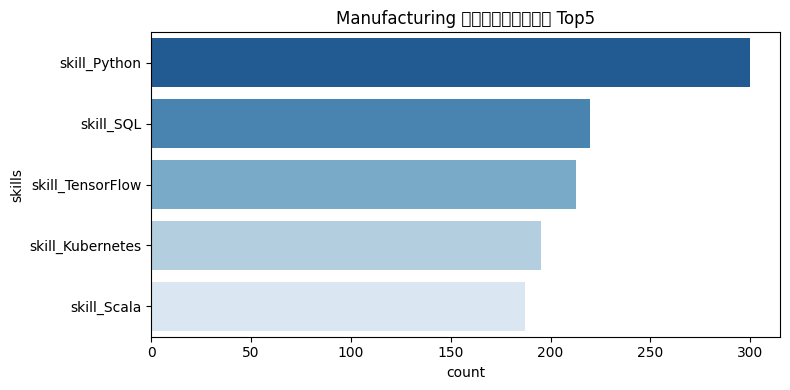

/var/folders/k7/3d7f1jzs6t18v3frf9bl8ysr0000gn/T/ipykernel_31059/2879734636.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=topn.values, y=topn.index, palette="Blues_r")
/var/folders/k7/3d7f1jzs6t18v3frf9bl8ysr0000gn/T/ipykernel_31059/2879734636.py:20: UserWarning: Glyph 23703 (\N{CJK UNIFIED IDEOGRAPH-5C97}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/k7/3d7f1jzs6t18v3frf9bl8ysr0000gn/T/ipykernel_31059/2879734636.py:20: UserWarning: Glyph 20301 (\N{CJK UNIFIED IDEOGRAPH-4F4D}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/k7/3d7f1jzs6t18v3frf9bl8ysr0000gn/T/ipykernel_31059/2879734636.py:20: UserWarning: Glyph 26368 (\N{CJK UNIFIED IDEOGRAPH-6700}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/k7/3d7f1jzs6t18v3frf9bl8ysr0000gn/T/ipykernel_31059/2879734636.py:20: U

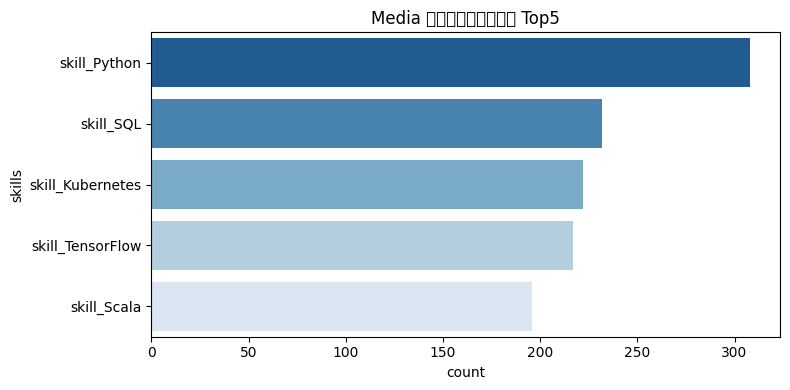

/var/folders/k7/3d7f1jzs6t18v3frf9bl8ysr0000gn/T/ipykernel_31059/2879734636.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=topn.values, y=topn.index, palette="Blues_r")
/var/folders/k7/3d7f1jzs6t18v3frf9bl8ysr0000gn/T/ipykernel_31059/2879734636.py:20: UserWarning: Glyph 23703 (\N{CJK UNIFIED IDEOGRAPH-5C97}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/k7/3d7f1jzs6t18v3frf9bl8ysr0000gn/T/ipykernel_31059/2879734636.py:20: UserWarning: Glyph 20301 (\N{CJK UNIFIED IDEOGRAPH-4F4D}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/k7/3d7f1jzs6t18v3frf9bl8ysr0000gn/T/ipykernel_31059/2879734636.py:20: UserWarning: Glyph 26368 (\N{CJK UNIFIED IDEOGRAPH-6700}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/k7/3d7f1jzs6t18v3frf9bl8ysr0000gn/T/ipykernel_31059/2879734636.py:20: U

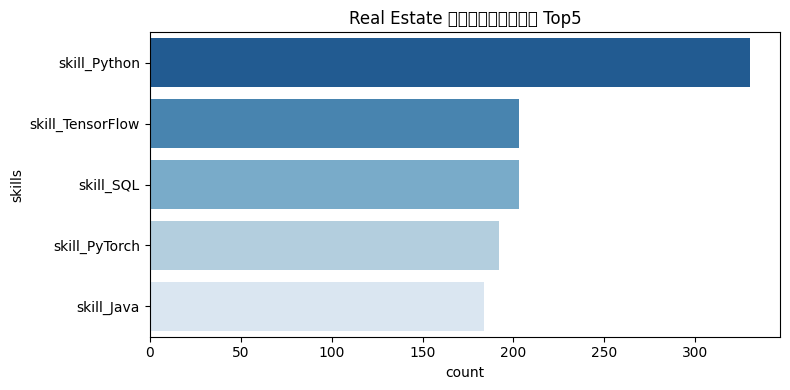

/var/folders/k7/3d7f1jzs6t18v3frf9bl8ysr0000gn/T/ipykernel_31059/2879734636.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=topn.values, y=topn.index, palette="Blues_r")
/var/folders/k7/3d7f1jzs6t18v3frf9bl8ysr0000gn/T/ipykernel_31059/2879734636.py:20: UserWarning: Glyph 23703 (\N{CJK UNIFIED IDEOGRAPH-5C97}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/k7/3d7f1jzs6t18v3frf9bl8ysr0000gn/T/ipykernel_31059/2879734636.py:20: UserWarning: Glyph 20301 (\N{CJK UNIFIED IDEOGRAPH-4F4D}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/k7/3d7f1jzs6t18v3frf9bl8ysr0000gn/T/ipykernel_31059/2879734636.py:20: UserWarning: Glyph 26368 (\N{CJK UNIFIED IDEOGRAPH-6700}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/k7/3d7f1jzs6t18v3frf9bl8ysr0000gn/T/ipykernel_31059/2879734636.py:20: U

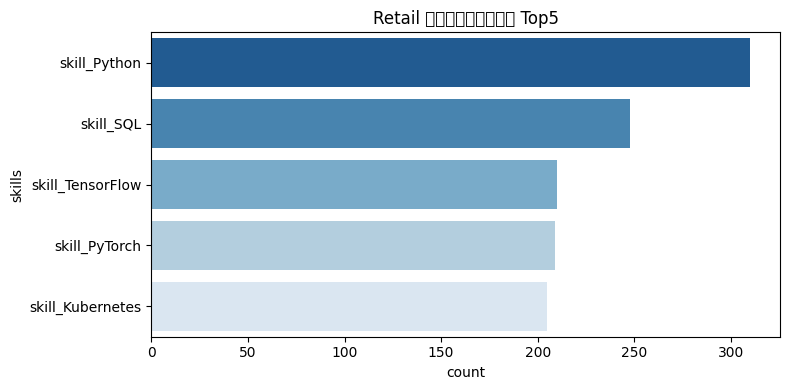

/var/folders/k7/3d7f1jzs6t18v3frf9bl8ysr0000gn/T/ipykernel_31059/2879734636.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=topn.values, y=topn.index, palette="Blues_r")
/var/folders/k7/3d7f1jzs6t18v3frf9bl8ysr0000gn/T/ipykernel_31059/2879734636.py:20: UserWarning: Glyph 23703 (\N{CJK UNIFIED IDEOGRAPH-5C97}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/k7/3d7f1jzs6t18v3frf9bl8ysr0000gn/T/ipykernel_31059/2879734636.py:20: UserWarning: Glyph 20301 (\N{CJK UNIFIED IDEOGRAPH-4F4D}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/k7/3d7f1jzs6t18v3frf9bl8ysr0000gn/T/ipykernel_31059/2879734636.py:20: UserWarning: Glyph 26368 (\N{CJK UNIFIED IDEOGRAPH-6700}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/k7/3d7f1jzs6t18v3frf9bl8ysr0000gn/T/ipykernel_31059/2879734636.py:20: U

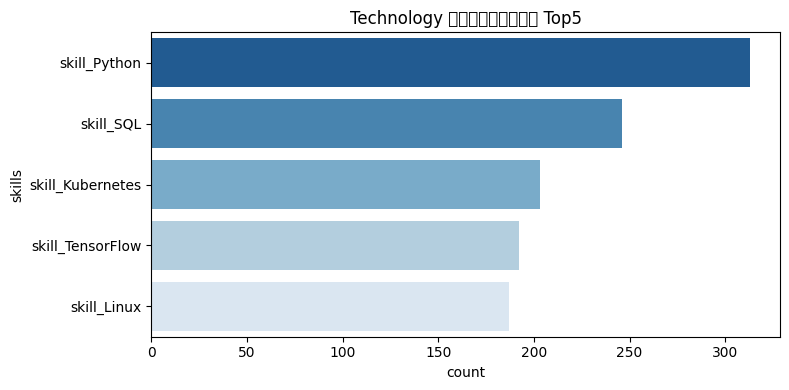

/var/folders/k7/3d7f1jzs6t18v3frf9bl8ysr0000gn/T/ipykernel_31059/2879734636.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=topn.values, y=topn.index, palette="Blues_r")
/var/folders/k7/3d7f1jzs6t18v3frf9bl8ysr0000gn/T/ipykernel_31059/2879734636.py:20: UserWarning: Glyph 23703 (\N{CJK UNIFIED IDEOGRAPH-5C97}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/k7/3d7f1jzs6t18v3frf9bl8ysr0000gn/T/ipykernel_31059/2879734636.py:20: UserWarning: Glyph 20301 (\N{CJK UNIFIED IDEOGRAPH-4F4D}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/k7/3d7f1jzs6t18v3frf9bl8ysr0000gn/T/ipykernel_31059/2879734636.py:20: UserWarning: Glyph 26368 (\N{CJK UNIFIED IDEOGRAPH-6700}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/k7/3d7f1jzs6t18v3frf9bl8ysr0000gn/T/ipykernel_31059/2879734636.py:20: U

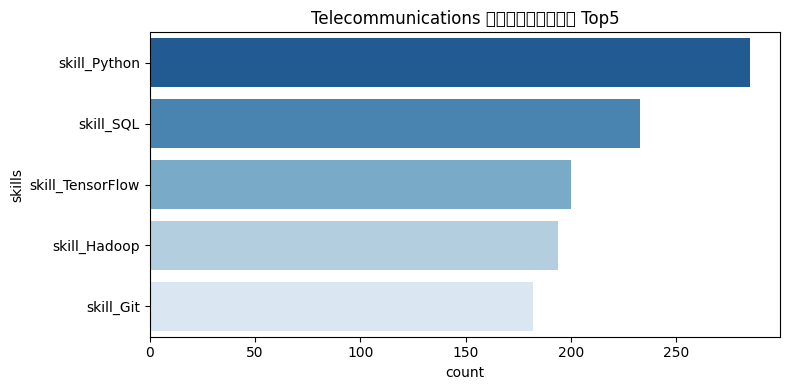

/var/folders/k7/3d7f1jzs6t18v3frf9bl8ysr0000gn/T/ipykernel_31059/2879734636.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=topn.values, y=topn.index, palette="Blues_r")
/var/folders/k7/3d7f1jzs6t18v3frf9bl8ysr0000gn/T/ipykernel_31059/2879734636.py:20: UserWarning: Glyph 23703 (\N{CJK UNIFIED IDEOGRAPH-5C97}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/k7/3d7f1jzs6t18v3frf9bl8ysr0000gn/T/ipykernel_31059/2879734636.py:20: UserWarning: Glyph 20301 (\N{CJK UNIFIED IDEOGRAPH-4F4D}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/k7/3d7f1jzs6t18v3frf9bl8ysr0000gn/T/ipykernel_31059/2879734636.py:20: UserWarning: Glyph 26368 (\N{CJK UNIFIED IDEOGRAPH-6700}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/k7/3d7f1jzs6t18v3frf9bl8ysr0000gn/T/ipykernel_31059/2879734636.py:20: U

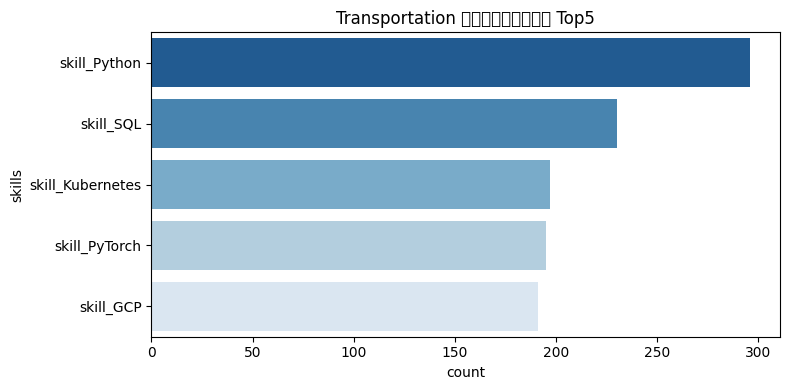

In [16]:
plot_top_skills_all_jobs(df_skills, n=5)
